In [6]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/tp_final_vision_artificial")

DATA_DIR = PROJECT_ROOT / "data"
MASKS_DIR = DATA_DIR / "masks"
PERCEPTS_DIR = DATA_DIR / "percepts"
SIGNALS_DIR = DATA_DIR / "electrical_signals"
METADATA_DIR = DATA_DIR / "metadata"

SRC_DIR = PROJECT_ROOT / "src"

for d in [MASKS_DIR, PERCEPTS_DIR, SIGNALS_DIR, METADATA_DIR, SRC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MASKS_DIR:", MASKS_DIR)
print("PERCEPTS_DIR:", PERCEPTS_DIR)
print("SIGNALS_DIR:", SIGNALS_DIR)
print("METADATA_DIR:", METADATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/tp_final_vision_artificial
MASKS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/masks
PERCEPTS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/percepts
SIGNALS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/electrical_signals
METADATA_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata


In [7]:
# dependencias

# Uninstall potentially conflicting numpy and pandas to ensure a clean slate
!pip uninstall -y numpy pandas

# Install numpy version compatible with pulse2percept
!pip install -q numpy==1.26.4

# Install pandas version compatible with google-colab (and numpy 1.26.4)
!pip install -q pandas==2.2.2

# Install the rest of the required packages
!pip install -q pulse2percept pillow matplotlib


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pulse2percept 0.9.0 requires pandas, which is not installed.
esda 2.9.0 requires pandas>=2.1, which is not installed.
gradio 5.50.0 requires pandas<3.0,>=1.0, which is not installed.
tsfresh 0.21.2 requires pandas>=0.25.0, which is not installed.
mizani 0.13.5 requires pandas>=2.2.0, which is not installed.
bqplot 0.12.47 requires pandas>=1.0.0, which is not installed.
mapclassify 2.10.0 requires pandas>=2.1, which is not installed.
sklearn-pandas 2.2.0 requires pandas>=1.1.4, which is not installed.
segregation 2.5.4 requires pandas, which is not installed.
spaghetti 1.7.6 requires pandas!=1.5.0,>=1

In [15]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



from src.simulation.percept_generation import (
    generate_percepts,
    print_percept_summary,
)

In [9]:
# config

METADATA_MASKS_FILE = METADATA_DIR / "metadata_masks.csv"
OUTPUT_METADATA_FILE = METADATA_DIR / "metadata_percepts.csv"

TARGET_CLASSES = [
    "person",
    "car",
    "chair",
    "dining table",
]

IMPLANTS = [
    "argus2",
    "prima",
    "alphams",
]

MAX_PER_CLASS = 900

INPUT_SIZE = 256
PERCEPT_SIZE = 256

XRANGE = (-10, 10)
YRANGE = (-10, 10)

print("Metadata masks:", METADATA_MASKS_FILE)
print("Existe metadata masks:", METADATA_MASKS_FILE.exists())

print("Output metadata:", OUTPUT_METADATA_FILE)
print("Percepts dir:", PERCEPTS_DIR)
print("Signals dir:", SIGNALS_DIR)

Metadata masks: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_masks.csv
Existe metadata masks: True
Output metadata: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_percepts.csv
Percepts dir: /content/drive/MyDrive/tp_final_vision_artificial/data/percepts
Signals dir: /content/drive/MyDrive/tp_final_vision_artificial/data/electrical_signals


In [10]:
# genero perceptos

summary = generate_percepts(
    metadata_masks_file=METADATA_MASKS_FILE,
    output_percepts_dir=PERCEPTS_DIR,
    output_signals_dir=SIGNALS_DIR,
    output_metadata_file=OUTPUT_METADATA_FILE,
    masks_dir=MASKS_DIR,
    target_classes=TARGET_CLASSES,
    implants=IMPLANTS,
    max_per_class=MAX_PER_CLASS,
    input_size=INPUT_SIZE,
    percept_size=PERCEPT_SIZE,
    xrange=XRANGE,
    yrange=YRANGE,
    random_state=42,
    skip_existing=True,
)

print_percept_summary(summary)

Máscaras seleccionadas:
label
car             900
chair           900
person          900
dining table    624
Name: count, dtype: int64
Total: 3324

Construyendo ScoreboardModel...
Modelo listo.

Implante: argus2

Implante: prima

Implante: alphams
Tamaño del percepto: (256, 256)
Tamaño de la señal: (1600, 1)
1500/3324
1600/3324
1700/3324
1800/3324
1900/3324
2000/3324
2100/3324
2200/3324
2300/3324
2400/3324
2500/3324
2600/3324
2700/3324
2800/3324
2900/3324
3000/3324
3100/3324
3200/3324
3300/3324

Listo.
Máscaras seleccionadas: 3324
Perceptos/señales nuevos guardados: 1905
Perceptos/señales reutilizados: 8067
Máscaras salteadas: 0
Errores: 0
Filas metadata: 9972
Metadata: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_percepts.csv
Percepts dir: /content/drive/MyDrive/tp_final_vision_artificial/data/percepts
Signals dir: /content/drive/MyDrive/tp_final_vision_artificial/data/electrical_signals

Distribución por implante y clase:
    implant         label    n
0 

In [11]:
# reviso metadata generada

df_percepts = pd.read_csv(OUTPUT_METADATA_FILE)

print(df_percepts.shape)
display(df_percepts.head())

print("\nColumnas:")
print(df_percepts.columns.tolist())

print("\nArchivos de perceptos encontrados:")
print(df_percepts["percept_path"].apply(lambda p: Path(p).exists()).sum(), "/", len(df_percepts))

print("\nArchivos de señales encontrados:")
print(df_percepts["signal_path"].apply(lambda p: Path(p).exists()).sum(), "/", len(df_percepts))

(9972, 8)


,sample_id,image_id,ann_id,label,implant,mask_path,signal_path,percept_path
0,1000_1304800,1000,1304800,person,alphams,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
1,1000_1304800,1000,1304800,person,argus2,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
2,1000_1304800,1000,1304800,person,prima,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
3,1000_1311471,1000,1311471,person,alphams,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
4,1000_1311471,1000,1311471,person,argus2,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...



Columnas:
['sample_id', 'image_id', 'ann_id', 'label', 'implant', 'mask_path', 'signal_path', 'percept_path']

Archivos de perceptos encontrados:
9972 / 9972

Archivos de señales encontrados:
9972 / 9972


In [12]:
# verifico que los archivos existan

n_exists = df_percepts["percept_path"].apply(lambda p: Path(p).exists()).sum()

print(f"Perceptos encontrados: {n_exists}/{len(df_percepts)}")

Perceptos encontrados: 9972/9972


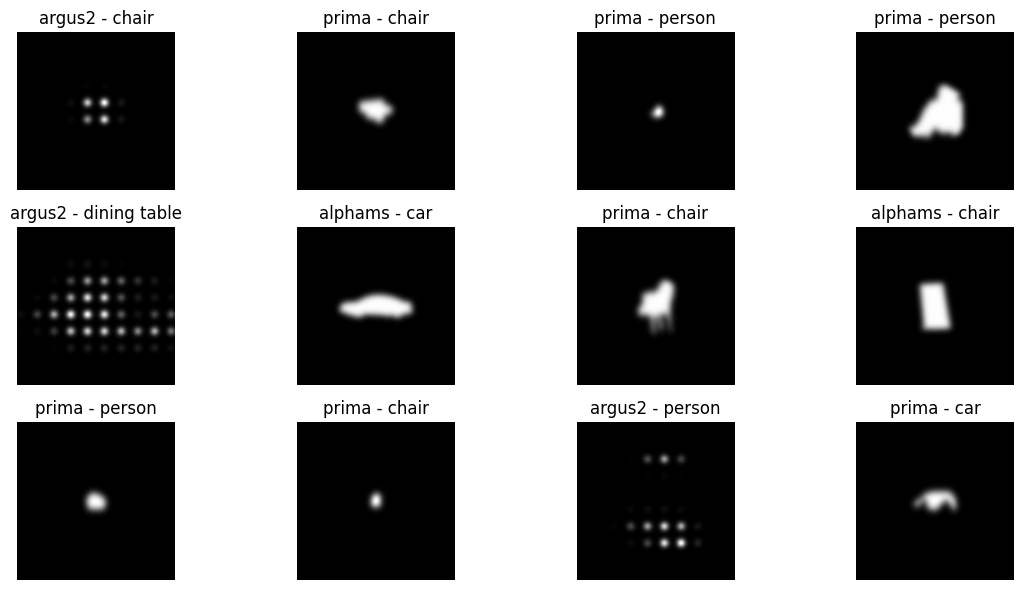

In [13]:
# visualizo perceptos


sample = df_percepts.sample(min(12, len(df_percepts)), random_state=42)

plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sample.iterrows(), start=1):
    img = Image.open(row["percept_path"])

    plt.subplot(3, 4, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"{row['implant']} - {row['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# veo una señal

row = df_percepts.iloc[0]

signal_file = np.load(row["signal_path"])
signal = signal_file["signal"]

print("Sample ID:", row["sample_id"])
print("Image ID:", row["image_id"])
print("Ann ID:", row["ann_id"])
print("Label:", row["label"])
print("Implant:", row["implant"])
print("Signal shape:", signal.shape)
print("Signal min:", signal.min())
print("Signal max:", signal.max())

Sample ID: 1000_1304800
Image ID: 1000
Ann ID: 1304800
Label: person
Implant: alphams
Signal shape: (1600, 1)
Signal min: 0.0
Signal max: 1.0
